In [19]:
!pip install numpy scipy matplotlib

Mass Parameters Of The Space Mechanics System.

In [20]:
# NASA Space Shuttle yaklaşık değerleri

ORBITER_MASS = 109000      # kg
EXTERNAL_TANK = 760000     # kg (yakıt dolu)
SRB_TOTAL = 1180000        # kg (iki SRB)

TOTAL_MASS = ORBITER_MASS + EXTERNAL_TANK + SRB_TOTAL

print("Toplam Kalkış Kütlesi:", TOTAL_MASS/1000, "ton")


Toplam Kalkış Kütlesi: 2049.0 ton


Simple 2D Launch Simulation.

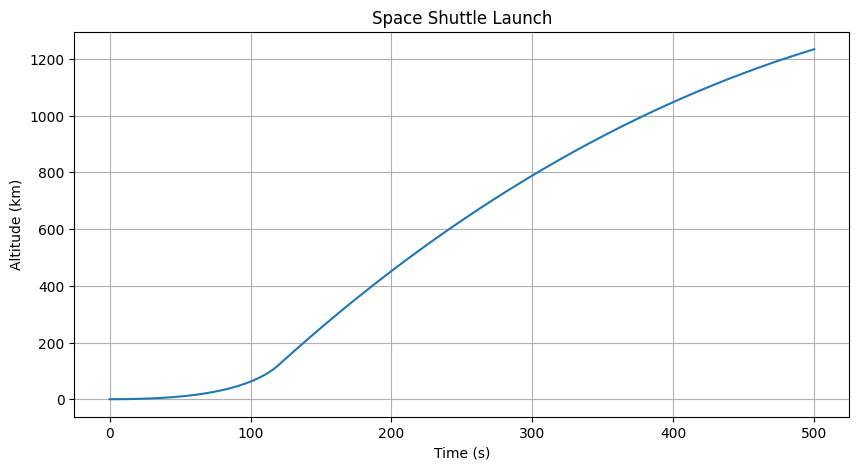

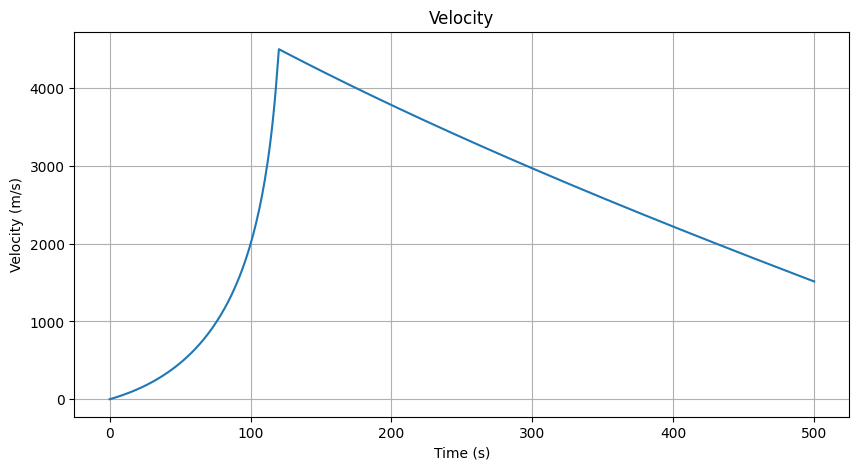

In [21]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

G = 6.67430e-11
M_EARTH = 5.972e24
R_EARTH = 6371000

thrust = 3.0e7          # Newton
burn_time = 120         # saniye

m0 = 2.0e6              # başlangıç kütlesi
mf = 1.0e5              # son kütle

mdot = (m0 - mf) / burn_time

def rocket(t, y):

    altitude = y[0]
    velocity = y[1]

    r = R_EARTH + altitude

    if t < burn_time:
        mass = m0 - mdot*t
        T = thrust
    else:
        mass = mf
        T = 0

    gravity = G*M_EARTH/r**2

    dalt = velocity
    dvel = T/mass - gravity

    return [dalt, dvel]

sol = solve_ivp(
    rocket,
    [0,500],
    [0,0],
    max_step=1
)

t = sol.t
h = sol.y[0]/1000
v = sol.y[1]

plt.figure(figsize=(10,5))
plt.plot(t,h)
plt.xlabel("Time (s)")
plt.ylabel("Altitude (km)")
plt.title("Space Shuttle Launch")
plt.grid()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(t,v)
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity")
plt.grid()
plt.show()

Orbital Simulation Around The Earth.

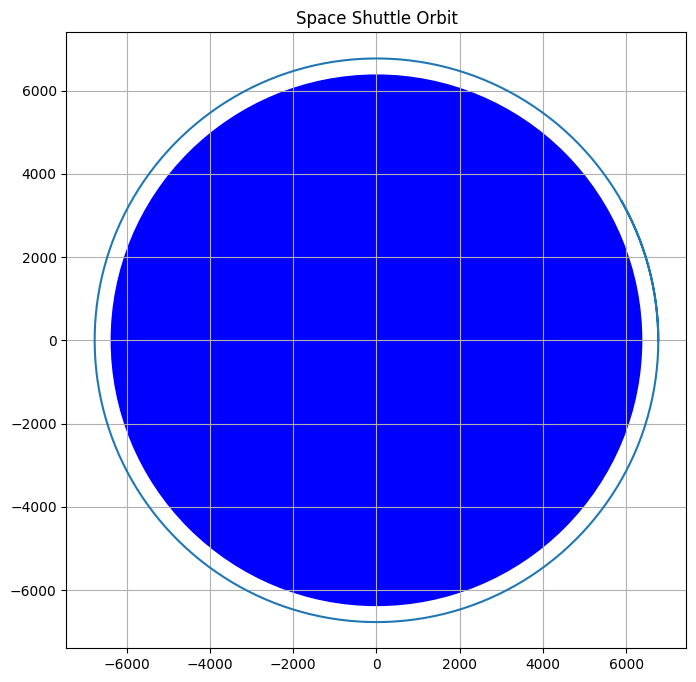

In [22]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

mu = 3.986004418e14

r0 = 6771000
v0 = np.sqrt(mu/r0)

state0 = [r0,0,0,v0]

def orbit(t,y):

    x,ypos,vx,vy = y

    r = np.sqrt(x**2+ypos**2)

    ax = -mu*x/r**3
    ay = -mu*ypos/r**3

    return [vx,vy,ax,ay]

sol = solve_ivp(
    orbit,
    [0,6000],
    state0,
    max_step=10
)

x = sol.y[0]/1000
y = sol.y[1]/1000

plt.figure(figsize=(8,8))
plt.plot(x,y)

earth = plt.Circle((0,0),6371,color='blue')
plt.gca().add_patch(earth)

plt.axis('equal')
plt.grid()
plt.title("Space Shuttle Orbit")
plt.show()

Blueprint Simulation Rocket Sketch Drawing.

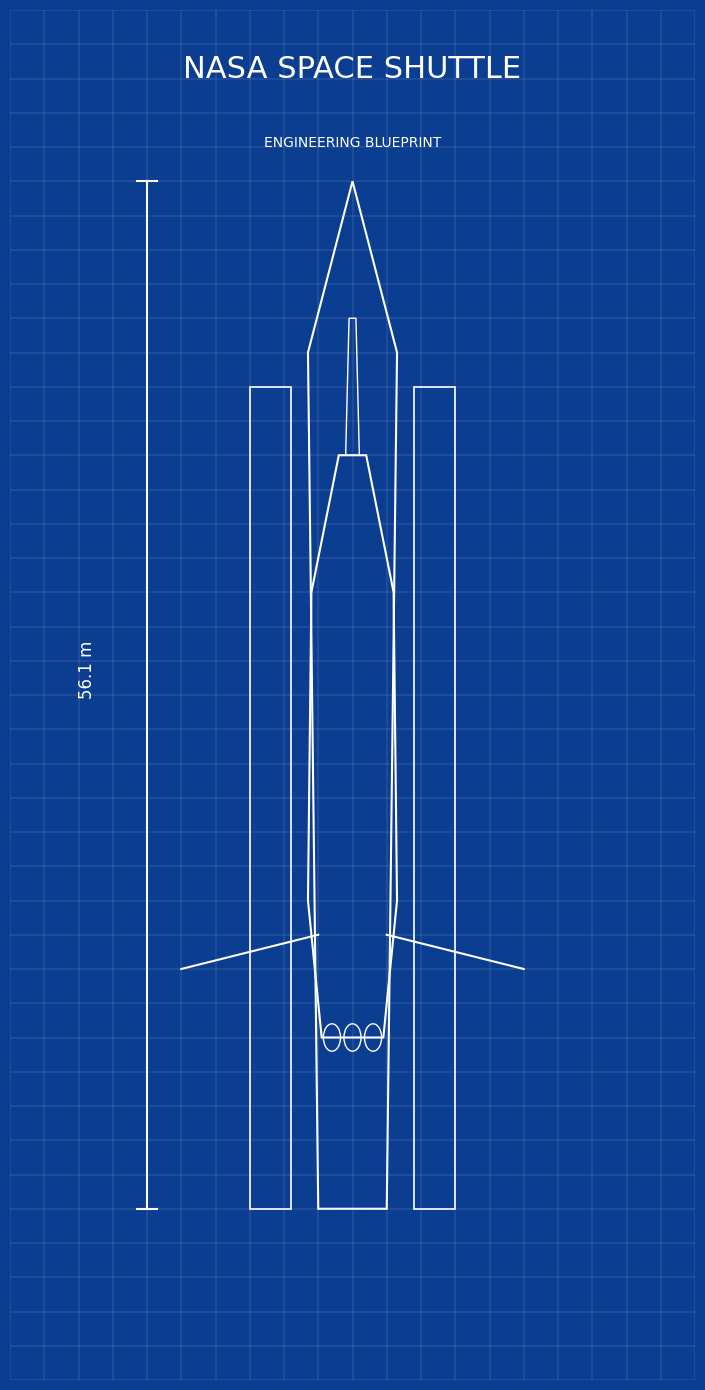

In [24]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle, Ellipse
import numpy as np

fig, ax = plt.subplots(figsize=(10, 14))

# Blueprint arkaplanı
ax.set_facecolor("#0b3d91")
fig.patch.set_facecolor("#0b3d91")

# Grid
for x in np.arange(-10, 11, 1):
    ax.axvline(x, color="white", alpha=0.08)

for y in np.arange(0, 41, 1):
    ax.axhline(y, color="white", alpha=0.08)

# Harici yakıt tankı
tank = Polygon([
    (-1,5),
    (1,5),
    (1.3,30),
    (0,35),
    (-1.3,30)
], fill=False, edgecolor="white", linewidth=1.5)

ax.add_patch(tank)

# Sol SRB
left_srb = Rectangle((-3,5),1.2,24,
                     fill=False,
                     edgecolor="white",
                     linewidth=1.2)

ax.add_patch(left_srb)

# Sağ SRB
right_srb = Rectangle((1.8,5),1.2,24,
                      fill=False,
                      edgecolor="white",
                      linewidth=1.2)

ax.add_patch(right_srb)

# Orbiter gövde
orbiter = Polygon([
    (-0.9,10),
    (0.9,10),
    (1.3,14),
    (1.2,23),
    (0.4,27),
    (-0.4,27),
    (-1.2,23),
    (-1.3,14)
],
fill=False,
edgecolor="white",
linewidth=1.5)

ax.add_patch(orbiter)

# Kanatlar
ax.plot([-5,-1],[12,13],
        color="white",
        linewidth=1.5)

ax.plot([5,1],[12,13],
        color="white",
        linewidth=1.5)

# Kuyruk
tail = Polygon([
    (-0.2,27),
    (0.2,27),
    (0.1,31),
    (-0.1,31)
],
fill=False,
edgecolor="white")

ax.add_patch(tail)

# Motorlar
for x in [-0.6,0,0.6]:
    motor = Ellipse((x,10),0.5,0.8,
                    fill=False,
                    edgecolor="white")
    ax.add_patch(motor)

# Ölçülendirme çizgileri
ax.plot([-6,-6],[5,35],
        color="white")

ax.plot([-6.3,-5.7],[35,35],
        color="white")

ax.plot([-6.3,-5.7],[5,5],
        color="white")

ax.text(-8,20,
        "56.1 m",
        color="white",
        rotation=90,
        fontsize=12)

# Başlık
ax.text(0,
        38,
        "NASA SPACE SHUTTLE",
        color="white",
        fontsize=22,
        ha="center")

ax.text(0,
        36,
        "ENGINEERING BLUEPRINT",
        color="white",
        fontsize=10,
        ha="center")

ax.set_xlim(-10,10)
ax.set_ylim(0,40)

ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()
plt.show()

# Theoretical Background

This project generates a NASA-style aerospace blueprint and is based on the geometric representation of launch vehicles commonly used in engineering design.

## Rocket Geometry

A launch vehicle can be approximated as a combination of simple geometric structures:

### Nose Cone

The nose cone is modeled as a conical section:

$$
A_{base} = \pi r^2
$$

where:

* $r$ = base radius

The volume of a cone is:

$$
V = \frac{1}{3}\pi r^2 h
$$

where:

* $h$ = cone height

---

## Cylindrical Stages

Most rocket stages are approximated as cylinders.

Cylinder volume:

$$
V = \pi r^2 h
$$

Cylinder surface area:

$$
A = 2\pi r h + 2\pi r^2
$$

where:

* $r$ = radius
* $h$ = height

---

## Mass Distribution

Total launch mass is:

$$
m_{total} =
m_{payload}
+
m_{structure}
+
m_{propellant}
$$

where:

* $m_{payload}$ = payload mass
* $m_{structure}$ = structural mass
* $m_{propellant}$ = propellant mass

---

## Center of Mass

The center of mass along the vehicle axis is:

$$
x_{cm}
======

\frac{
\sum_i m_i x_i
}{
\sum_i m_i
}
$$

where:

* $m_i$ = component mass
* $x_i$ = component position

---

## Rocket Thrust

Rocket thrust is defined as:

$$
F
=

\dot{m}v_e
+
(p_e-p_a)A_e
$$

where:

* $\dot{m}$ = mass flow rate
* $v_e$ = exhaust velocity
* $p_e$ = exhaust pressure
* $p_a$ = atmospheric pressure
* $A_e$ = nozzle exit area

---

## Newton's Second Law

Vehicle acceleration is determined by:

$$
F = ma
$$

therefore:

$$
a = \frac{F}{m}
$$

---

## Gravitational Force

The gravitational attraction between Earth and the vehicle is:

$$
F_g
===

G
\frac{Mm}{r^2}
$$

where:

* $G = 6.67430 \times 10^{-11}\ \mathrm{m^3,kg^{-1},s^{-2}}$
* $M$ = Earth mass
* $m$ = vehicle mass
* $r$ = distance from Earth's center

---

## Orbital Velocity

For a circular orbit:

$$
v
=

\sqrt{
\frac{\mu}{r}
}
$$

where:

$$
\mu = GM
$$

is Earth's gravitational parameter.

---

## Engineering Blueprint Concept

A blueprint is a scaled technical representation of an engineering system.

The drawing consists of:

* Side view
* Front view
* Geometric dimensions
* Structural annotations
* Propulsion layout
* Stage separation interfaces

The objective is to visualize vehicle architecture using engineering-style drafting techniques similar to those used in aerospace design documentation.
